# Distribution functions

An integral part of `synthpop` is the ability to sample a distribution function, for example the galaxy stellar mass function. 

`synthpop` has two types of distribution functions, parametric distribution functions (e.g. a Schechhter function) and binned distribution functions. Both include some common methods. 

In [1]:
import synthpop.distribution_functions as dfs
import numpy as np
from unyt import Msun, Mpc
from astropy.cosmology import Planck18 as cosmology

## Parametric Distribution Functions

At present `synthpop` contains three distribution parameterisations including a Schechter function, a DoubleSchecter function, and a double power-law. 

There are also various pre-defined parametric distribution functions.

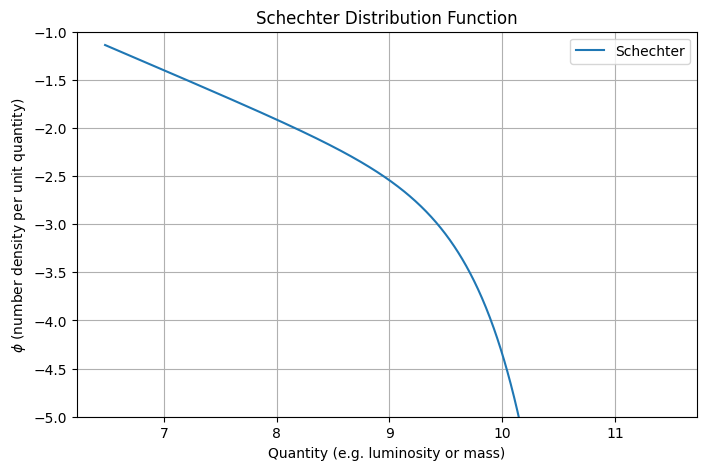

In [2]:
# Define and plot an arbitrary Schechter galaxy stellar massfunction

x_star = 3e9 * Msun     # Characteristic luminosity
phi_star = 1e-3 * (1/Mpc**3)    # Normalization
alpha = -1.5 

df = dfs.Schechter(x_star=x_star, alpha=alpha, phi_star=phi_star)

df.plot(ylimits=(-5, -1))



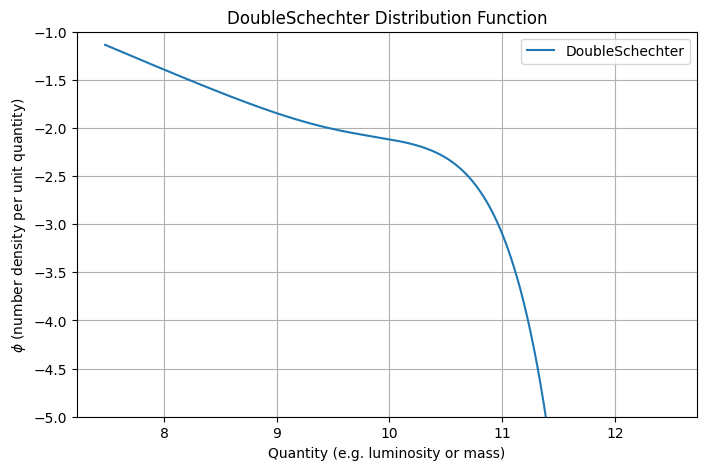

In [3]:
# Define and plot an arbitrary Double Schechter galaxy stellar massfunction

x_star = 3e10 * Msun     
phi1_star = 5e-3 * (1/Mpc**3)    
phi2_star = 1e-3 * (1/Mpc**3) 
alpha1 = -0.5
alpha2 = -1.5

df2 = dfs.DoubleSchechter(x_star=x_star, alpha1=alpha1, alpha2=alpha2, phi1_star=phi1_star, phi2_star=phi2_star)

df2.plot(ylimits=(-5, -1))

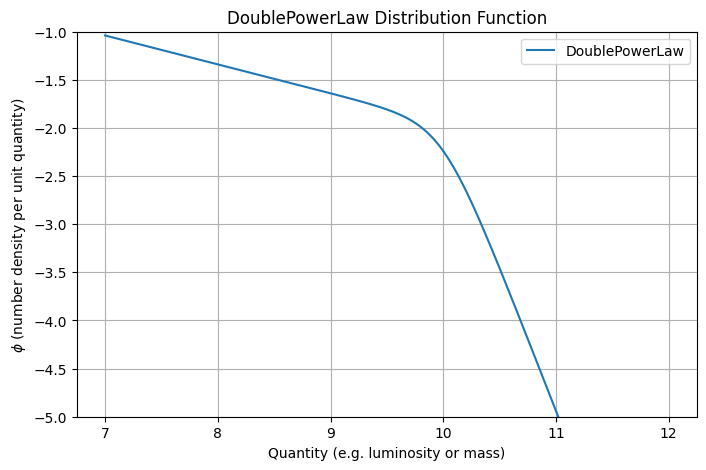

In [4]:
# Define and plot an arbitrary Double Power-law galaxy stellar massfunction

x_star = 1e10 * Msun     
phi_star = 5e-3 * (1/Mpc**3)    
alpha = -1.3
beta = -4.

df3 = dfs.DoublePowerLaw(x_star=x_star, alpha=alpha, beta=beta, phi_star=phi_star)

df3.plot(ylimits=(-5, -1))

### Useful methods

The parent distribution function class includes a handful of useful methods:

#### Number density

The number density is given by the integral of the distribution function, corresponding to its zeroth moment,

$$
n = \int \phi(M)\, dM,
$$

and represents the total number of objects per unit comoving volume.

Each distribution class implements a `zeroth_moment()` method, allowing the moment to be evaluated directly from the underlying parameterisation. For convenience, the parent class also provides a `calculate_number_density()` method, which returns the number density in physically meaningful units, handling the necessary unit conversions internally.

By default, these methods perform the calculation over the full mass range, $M= 0\rightarrow \infty$. However, finite integration limits can be supplied if required, allowing the number density to be evaluated over a specified mass interval.

It is important to note that number density for a Schechter function will diverge for $\alpha<-1$ in which case evaluating to $0$ will error.


In [5]:
print(fr'n = {df.calculate_number_density().to("1/Mpc**3"):.2e}')
print(fr'n(M>10^{{9}}\ M_{{\\odot}}) = {df.calculate_number_density(xmin=1e9 * Msun).to("1/Mpc**3"):.2e}')

n = nan Mpc**(-3)
n(M>10^{9}\ M_{\\odot}) = nan Mpc**(-3)


#### Stellar mass density

The stellar mass density is the first moment of the stellar mass function,

$$
\rho_\star = \int M \, \phi(M) \, dM,
$$

and provides a measure of the total stellar mass per unit comoving volume.

Each distribution class implements a `first_moment()` method, allowing the moment to be evaluated directly from the underlying parameterisation. For convenience, the parent class also provides a `calculate_mass_density()` method, which returns the stellar mass density in physically meaningful units, handling the necessary conversions internally.

In addition, the parent class includes a method for calculating the corresponding cosmic stellar mass density parameter, $\Omega_\star$, for a specified cosmology. This method accepts an `astropy.cosmology` instance and computes

$$
\Omega_\star = \frac{\rho_\star}{\rho_{\rm crit}},
$$

where $\rho_{\rm crit}$ is the critical density of the supplied cosmology. This provides a convenient way to compare stellar mass densities across different cosmological models and with values reported in the literature.

By default, both methods perform the calculation over the full mass range, $M = 0 \rightarrow \infty$. However, finite integration limits can be supplied if required.

In [6]:
print(fr'\rho_star = {df.calculate_mass_density().to("Msun/Mpc**3"):.2e}')
print(fr'\rho_star(10^{{9}} < M/M_{{\\odot}} < 10^{{11}}) = {df.calculate_mass_density(xmax=1e11 * Msun, xmin=1e9 * Msun).to("Msun/Mpc**3"):.2e}')
print(fr'\Omega_star = {df.calculate_omega_star(cosmology):.2e}')

\rho_star = 5.32e+06 Msun/Mpc**3
\rho_star(10^{9} < M/M_{\\odot} < 10^{11}) = 2.20e+06 Msun/Mpc**3
\Omega_star = 4.19e-05 dimensionless


### Sampling the distribution function

One particularly useful method in the context of `synthpop` is the ability to sample the distribution function:

Number of galaxies: 312670
Range of masses: (1.00e+07, 1.93e+10)
total mass density: (4.99e+06 Mpc**(-3))
analytical distribution function integral: (4.97e+06 Msun/Mpc**3)


/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/distribution_functions.py:358: RuntimeWarning: divide by zero encountered in log10
  plt.step(edges[:-1], np.log10(phi_sampled), where='post')


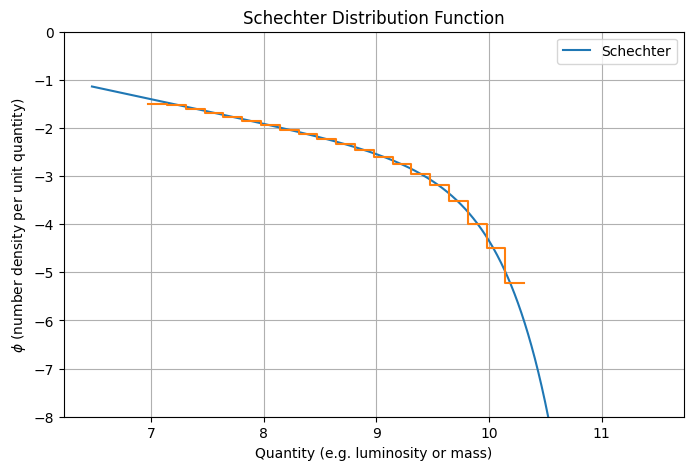

In [7]:
volume = 1E7 * Mpc**3      # Mpc^3
xmin = 1e7 * Msun
xmax = 1e11 * Msun

samples = df.sample(xmin=xmin, xmax=xmax, volume=volume)

# Check the number of galaxies sampled
print(f'Number of galaxies: {len(samples)}')

# Check the range of masses
print(f'Range of masses: ({np.min(samples):.2e}, {np.max(samples):.2e})')

# Calculate the total mass density in the sampled galaxies and compare to the integral of the distribution function
print(f'total mass density: ({np.sum(samples)/volume:.2e})')

# A quick to check to see if this matches the integral of the distribution function over the same mass range. This should be close to the total mass density calculated above, but may not be exact due to the finite number of samples and the stochastic nature of the sampling process. Increasing the volume and/or the number of samples should improve the agreement between these two values.
print(f'analytical distribution function integral: ({df.calculate_mass_density(xmin=xmin, xmax=xmax).to("Msun/Mpc**3"):.2e})')

df.plot(ylimits=(-8., 0.), samples=samples, volume=volume)


### Pre-defined distribution functions

Driver2022_SingleSchechter
1.80e+08 Msun/Mpc**3 8.26


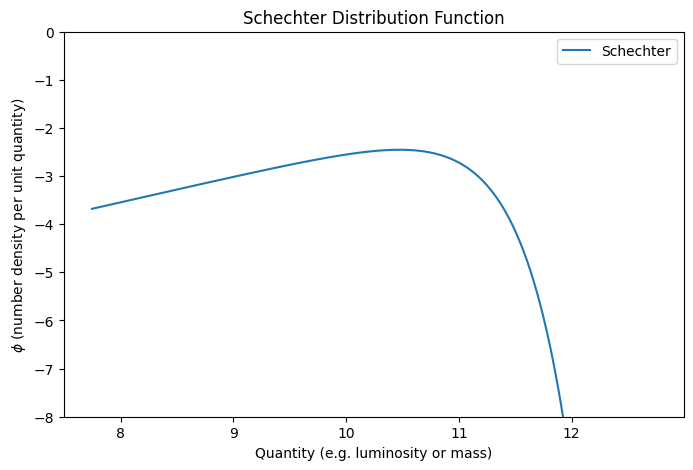

Driver2022_DoubleSchechter
2.46e+08 Msun/Mpc**3 8.39


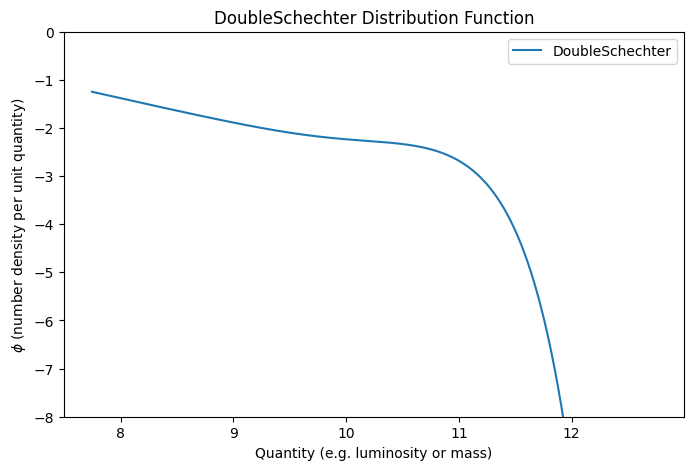

In [8]:
for df_name in dfs.predefined_distribution_functions:
    print(df_name)

    pd_df = getattr(dfs, df_name)

    print(f'{pd_df.calculate_mass_density().to("Msun/Mpc**3"):.2e} {np.log10(pd_df.calculate_mass_density().to("Msun/Mpc**3")):.2f}')
    pd_df.plot(ylimits=(-8., 0.), grid=False)

## Binned Distribution Functions

We can also define a distribution function using a binned version.

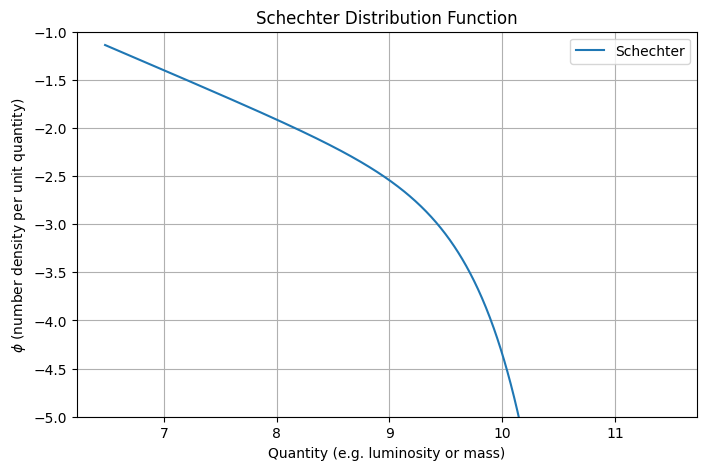

----------
SUMMARY OF BINNED DISTRIBUTION FUNCTION
Name: None
8.10e+00 dex: 1.08e-02 Mpc**(-3)
8.30e+00 dex: 8.43e-03 Mpc**(-3)
8.50e+00 dex: 6.40e-03 Mpc**(-3)
8.70e+00 dex: 4.74e-03 Mpc**(-3)
8.90e+00 dex: 3.51e-03 Mpc**(-3)
9.10e+00 dex: 2.38e-03 Mpc**(-3)
9.30e+00 dex: 1.43e-03 Mpc**(-3)
9.50e+00 dex: 7.98e-04 Mpc**(-3)
9.70e+00 dex: 3.57e-04 Mpc**(-3)
9.90e+00 dex: 9.70e-05 Mpc**(-3)
1.01e+01 dex: 2.00e-05 Mpc**(-3)
1.03e+01 dex: 1.00e-06 Mpc**(-3)
1.05e+01 dex: 1.00e-06 Mpc**(-3)
1.07e+01 dex: 0.00e+00 Mpc**(-3)
1.09e+01 dex: 0.00e+00 Mpc**(-3)
----------



/Users/sw376/Dropbox/Research/projects/synthpop/venv/lib/python3.10/site-packages/unyt/array.py:1900: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)
/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/distribution_functions.py:158: RuntimeWarning: divide by zero encountered in log10
  plt.step(edges[:-1], np.log10(phi_sampled), where='post')


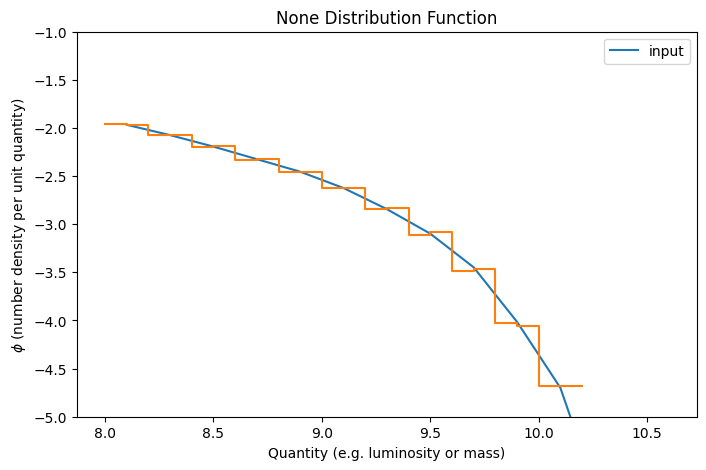

In [9]:

df.plot(ylimits=(-5, -1))


# Let's sample a parametric distribution ...

volume = 1E7 * Mpc**3      
xmin = 1e8 * Msun
xmax = 1e11 * Msun

samples = np.log10(df.sample(xmin=xmin, xmax=xmax, volume=volume))

# ... and then create a binned version
bin_width = 0.2 # dex
bin_edges = np.arange(
    np.log10(xmin.to("Msun").value), 
    np.log10(xmax.to("Msun").value) + bin_width, 
    bin_width)
N, bin_edges = np.histogram(samples, bins=bin_edges)
phi = N / (volume * bin_width)


# Create a BinnedDistributionFunction from the binned samples. Note: the x_units must be specified to ensure the correct units for the distribution function and bin_edges should be the logged quantity using the same units.
binned_df = dfs.BinnedDistributionFunction(
    bin_edges=bin_edges, 
    phi=phi,
    x_units=Msun,)

print(binned_df)

# Sample from the binned distribution function and plot the samples on top of the binned distribution function
new_samples = binned_df.sample(xmin=xmin, xmax=xmax, volume=volume)

binned_df.plot(ylimits=(-5, -1.), samples=new_samples, volume=volume, grid=False)
